# Fase 1 — EDA: calidad de señal

Cuarta tarea de la Fase 1 (ver `FASES.md`): padding, amplitud, NaN y derivaciones planas/corruptas. A diferencia de los notebooks anteriores, acá hay que leer la señal real desde los HDF5, así que se trabaja sobre una **muestra** por dataset (no los 366.854 registros completos) para que corra en tiempo razonable.

Definiciones:
- **Padding**: tramos contiguos al inicio/final del registro donde las 12 derivaciones son exactamente 0. CODE-15% y SaMi-Trop lo tienen (señal más corta que el largo fijo del array); PTB-XL no debería tenerlo (viene de WFDB nativo, sin recorte).
- **Duración real**: duración nominal menos el padding.
- **Amplitud**: máximo valor absoluto de la señal, medido solo sobre el tramo *no* padding (si se incluyera el padding, el 0 no afecta al máximo pero sí podría enmascarar otros problemas).
- **Derivación plana**: dentro del tramo no-padding, una derivación con desviación estándar ~0 — probable electrodo desconectado o fallo de adquisición, no señal real (un ECG real siempre tiene algo de variación).

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from eda_utils import LEADS, cargar_metadata, cargar_senales_lote

meta = cargar_metadata()
DATASETS = ["code15", "samitrop", "ptbxl"]
COLORES = {"code15": "#1f5fa8", "samitrop": "#c0392b", "ptbxl": "#2c8a4b"}
N_MUESTRA = 300

In [2]:
def medir_calidad(row, senal: np.ndarray) -> dict:
    n = senal.shape[0]
    ceros = np.all(senal == 0, axis=1)

    inicio = 0
    while inicio < n and ceros[inicio]:
        inicio += 1
    fin = 0
    while fin < n - inicio and ceros[n - 1 - fin]:
        fin += 1

    tramo_util = senal[inicio : n - fin] if fin > 0 else senal[inicio:]
    padding_frames = inicio + fin

    if tramo_util.shape[0] == 0:
        return {
            "record_id": row["record_id"], "dataset": row["dataset"],
            "padding_pct": 100.0, "duracion_real": 0.0,
            "amplitud_max": np.nan, "n_leads_planas": 12, "tiene_nan": bool(np.isnan(senal).any()),
        }

    return {
        "record_id": row["record_id"],
        "dataset": row["dataset"],
        "padding_pct": padding_frames / n * 100,
        "duracion_real": tramo_util.shape[0] / row["frecuencia"],
        "amplitud_max": float(np.abs(tramo_util).max()),
        "n_leads_planas": int((tramo_util.std(axis=0) < 1e-6).sum()),
        "tiene_nan": bool(np.isnan(senal).any()),
    }

In [3]:
resultados = []
for dataset in DATASETS:
    sub = meta[meta["dataset"] == dataset].sample(min(N_MUESTRA, (meta["dataset"] == dataset).sum()), random_state=2)
    señales = cargar_senales_lote(sub)
    for (_, row), senal in zip(sub.iterrows(), señales):
        resultados.append(medir_calidad(row, senal))

calidad = pd.DataFrame(resultados)
print(f"{len(calidad)} registros medidos ({N_MUESTRA} por dataset, salvo que el dataset tenga menos)")
calidad.head()

900 registros medidos (300 por dataset, salvo que el dataset tenga menos)


,record_id,dataset,padding_pct,duracion_real,amplitud_max,n_leads_planas,tiene_nan
0,1839134,code15,28.369141,7.335,6.632037,0,False
1,378849,code15,0.000000,10.240,14.527602,0,False
2,1658754,code15,28.369141,7.335,2.361895,0,False
3,1019859,code15,0.000000,10.240,8.593736,0,False
4,925637,code15,28.369141,7.335,2.941324,0,False


## NaN

Si aparece algún `True` acá, revisar esos `record_id` puntuales antes de entrenar — un NaN en la señal rompe cualquier modelo aguas abajo si no se filtra.

In [4]:
calidad.groupby("dataset")["tiene_nan"].agg(["sum", "count"])

,sum,count
dataset,,
code15,0,300
ptbxl,0,300
samitrop,0,300


## Padding

% del registro que es relleno de ceros, no señal real.

In [5]:
calidad.groupby("dataset")["padding_pct"].describe()

,count,mean,std,min,25%,50%,75%,max
dataset,,,,,,,,
code15,300.0,17.874268,14.097727,0.0,0.0,28.369141,28.369141,71.777344
ptbxl,300.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000
samitrop,300.0,13.481445,15.146010,0.0,0.0,0.000000,28.369141,61.718750


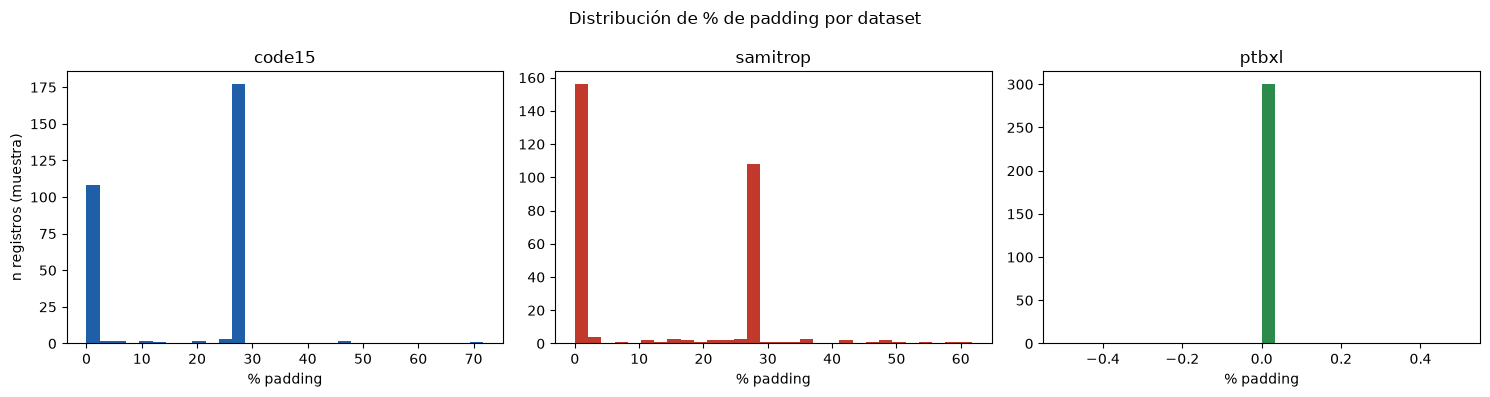

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, dataset in zip(axes, DATASETS):
    vals = calidad.loc[calidad["dataset"] == dataset, "padding_pct"]
    ax.hist(vals, bins=30, color=COLORES[dataset])
    ax.set_title(dataset)
    ax.set_xlabel("% padding")
axes[0].set_ylabel("n registros (muestra)")
fig.suptitle("Distribución de % de padding por dataset")
fig.tight_layout()
plt.show()

## Duración real (descontando padding)

In [7]:
calidad.groupby("dataset")["duracion_real"].describe()

,count,mean,std,min,25%,50%,75%,max
dataset,,,,,,,,
code15,300.0,8.409675,1.443607,2.89,7.335,7.335,10.24,10.24
ptbxl,300.0,10.000000,0.000000,10.00,10.000,10.000,10.00,10.00
samitrop,300.0,8.859500,1.550951,3.92,7.335,10.240,10.24,10.24


## Amplitud máxima (mV, sobre el tramo sin padding)

In [8]:
calidad.groupby("dataset")["amplitud_max"].describe()

,count,mean,std,min,25%,50%,75%,max
dataset,,,,,,,,
code15,300.0,5.979279,5.127435,0.038671,3.201255,4.286834,6.422057,29.607327
ptbxl,300.0,2.105410,0.818380,0.900000,1.524500,1.944000,2.498250,6.718000
samitrop,300.0,5.765693,4.100313,1.446233,3.146782,4.496571,6.758079,29.916637


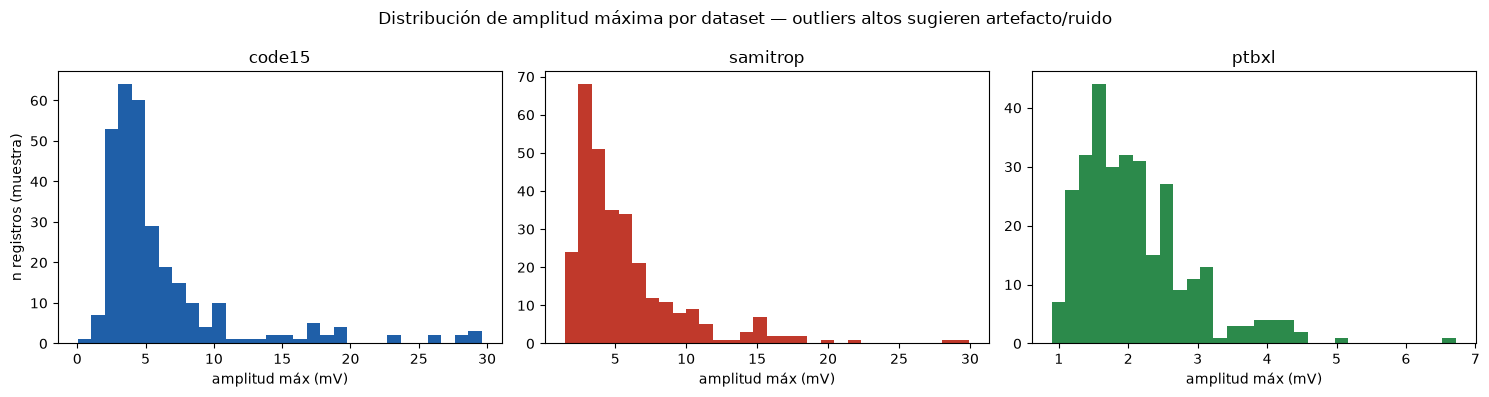

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, dataset in zip(axes, DATASETS):
    vals = calidad.loc[calidad["dataset"] == dataset, "amplitud_max"].dropna()
    ax.hist(vals, bins=30, color=COLORES[dataset])
    ax.set_title(dataset)
    ax.set_xlabel("amplitud máx (mV)")
axes[0].set_ylabel("n registros (muestra)")
fig.suptitle("Distribución de amplitud máxima por dataset — outliers altos sugieren artefacto/ruido")
fig.tight_layout()
plt.show()

## Derivaciones planas (posible electrodo desconectado)

In [10]:
calidad.groupby("dataset")["n_leads_planas"].agg(
    con_alguna_plana=lambda s: (s > 0).sum(),
    total="count",
)

,con_alguna_plana,total
dataset,,
code15,1,300
ptbxl,0,300
samitrop,1,300


## Peores casos (para inspección manual)

Si algo de lo anterior mostró outliers, estos son los `record_id` concretos para volver a `01_eda_senales.ipynb` y graficarlos.

In [11]:
print("Mayor padding:")
print(calidad.nlargest(5, "padding_pct")[["dataset", "record_id", "padding_pct"]])
print("\nMayor amplitud (posible artefacto):")
print(calidad.nlargest(5, "amplitud_max")[["dataset", "record_id", "amplitud_max"]])
print("\nCon derivaciones planas:")
print(calidad[calidad["n_leads_planas"] > 0][["dataset", "record_id", "n_leads_planas"]])

Mayor padding:
      dataset record_id  padding_pct
172    code15    999388    71.777344
307  samitrop    465998    61.718750
418  samitrop    830647    58.349609
533  samitrop    214348    54.296875
324  samitrop    394541    49.975586

Mayor amplitud (posible artefacto):
      dataset record_id  amplitud_max
575  samitrop    373073     29.916637
138    code15   1334395     29.607327
290    code15    167006     29.087446
412  samitrop    248136     28.877472
234    code15    344868     28.806423

Con derivaciones planas:
      dataset record_id  n_leads_planas
134    code15    641686               1
387  samitrop    218217               2
